# Assignment 3: Recurrent Neural Network (RNN) {-}

This assignment is designed to help you understand how recurrent neural networks are applied to a text classification task using the IMDB movie review dataset. You will go through the complete workflow, including loading the dataset, analyzing and preprocessing text data, building different RNN based models, and evaluating their performance. By experimenting with GRU, LSTM, and bidirectional variants, you will gain practical insight into how different RNN architectures affect classification accuracy and runtime efficiency. You will have to do:

1.  **(5 points) Coding tasks:** The following questions involve writing code to complete specific tasks.  
    1.1 *(1 point)* Analyze and preprocess the dataset to make it suitable for training RNN based models.  
    1.2 *(1 point)* Build an RNN model using GRU (Gated Recurrent Unit, https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU) instead of LSTM, following the demo code provided. Train the model and evaluate its performance on the test set.  
    1.3 *(1 point)* Build an RNN model using Bidirectional LSTM (BiLSTM, https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional). Train the model and evaluate its performance on the test set.  
    1.4 *(1 point)* Build an RNN model using Bidirectional GRU (BiGRU, https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional). Train the model and evaluate its performance on the test set.  
    1.5 *(1 point)* Compare the models built in this assignment, including LSTM, GRU, BiLSTM, and BiGRU, in terms of classification accuracy and runtime efficiency. Discuss your observations and explain the performance differences among these model variants.  

2.  **(5 points) Open discussion questions:** These discussion questions ask you to analyze and argue your points.  Feel free to include relevant code examples to strengthen your arguments.  
    2.1 *(1 point)* During preprocessing, text is converted into sequences of integers. Discuss how the choice of vocabulary size and handling of rare words can affect both model performance and generalization on unseen reviews.  
    2.2 *(1 point)* Bidirectional RNNs process sequences in both forward and backward directions. Discuss how this bidirectional context can improve sentiment classification and provide examples of review patterns where this might be especially helpful.  
    2.3 *(1 point)* Is the IMDB dataset class imbalanced, and how does its class distribution influence the selection of evaluation metrics? In your opinion, which evaluation metrics should be used to better understand the model’s performance, and why?  
    2.4 *(1 point)* Sequence length truncation is often applied to limit computational cost. Discuss the trade off between keeping longer sequences for richer context and truncating them for faster training and lower memory usage.  
    2.5 *(1 point)* Based on your overall findings, propose improvements or extensions to this assignment. These may include architectural changes, different preprocessing strategies, or alternative evaluation methods, and explain how they could lead to better sentiment classification performance.  


The dataset you will be working on is imdb_reviews. This dataset is a large movie review dataset. This dataset is for binary sentiment classification containing a set of 25,000 highly polar movie reviews for training, and 25,000 for testing. All the reviews have either a positive or negative sentiment. Reference: http://ai.stanford.edu/~amaas/data/sentiment/

Each data sample contains:
- label (tf.int64)
- text (tf.string)

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment3-notebook.ipynb: Jupyter notebook containing source code.

The submission folder is named DL4AI-\<StudentID>-Assignment3 (e.g., DL4AI-2012345-Assigment3) and then compressed with the same name.

### Evaluation {-}
The assignment will be evaluated based on how complete and correct your implementation is, and how clear and well reasoned your answers are in the open discussion questions. In particular:
- The models must be properly trained, showing neither clear overfitting nor clear underfitting.
- Model evaluation must be done on a separate test set that is not used for training or tuning.
- Your analysis should show a clear understanding of training behavior, convergence, and generalization.

In addition, your code must follow good Python coding practices, including clear structure, readable naming, appropriate comments, and compliance with a standard coding convention such as PEP 8.

### Deadline {-}
Please visit Canvas for details.

In [11]:
# Note: to enable GPU training in Colab, go to Runtime > Change runtime type > Hardware acceleration > Choose GPU from the drop-down list.

# Download tensorflow datasets
!pip install tensorflow_datasets

# Import libraries
import numpy as np
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt

In [12]:
# Load the IMDB movie review dataset, return text (movie review) and label (positive/negative)
train_dataset, val_dataset, test_dataset = tfds.load(name="imdb_reviews", split=('train[:80%]', 'train[80%:]', 'test'), as_supervised=True)

print("Training set: ", len(train_dataset), "samples")
print("Validation set: ", len(val_dataset), "samples")
print("Test set: ", len(test_dataset), "samples")

Training set:  20000 samples
Validation set:  5000 samples
Test set:  25000 samples


In [13]:
# Show same samples in the training set
for example, label in train_dataset.take(3):
  print('text: ', example.numpy())
  print('label: ', label.numpy())

text:  b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."
label:  0
text:  b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. 

## 1. Coding tasks

In [ ]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.1

In [14]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

def extract_text_and_label(dataset):
    """Helper function to convert TF Dataset to Tensors and Numpy arrays."""
    ds_numpy = tfds.as_numpy(dataset)
    ds_stacked = np.vstack(list(ds_numpy))

    # Extract text and labels
    X = tf.convert_to_tensor(list(map(lambda x: x[0], ds_stacked)), dtype=tf.string)
    y = np.array(list(map(lambda x: x[1], ds_stacked))).astype(np.int16)

    return X, y

# Apply to train, validation, and test sets
X_train, y_train = extract_text_and_label(train_dataset)
X_val, y_val = extract_text_and_label(val_dataset)
X_test, y_test = extract_text_and_label(test_dataset)

In [15]:
# Text Vectorization
# Set hyperparameters for preprocessing
VOCAB_SIZE = 10000        # Vocabulary size
MAX_SEQUENCE_LENGTH = 250 # Maximum length of each review sequence

# Initialize the TextVectorization layer
text_encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH
)

# Adapt the layer to learn the vocabulary from the training dataset
text_encoder.adapt(X_train)

# Print vocabulary information
vocab = np.array(text_encoder.get_vocabulary())
print(f"\nActual vocabulary size: {len(vocab)}")
print(f"Top 20 most common words: {vocab[:20]}")


Actual vocabulary size: 10000
Top 20 most common words: ['' '[UNK]' 'the' 'and' 'a' 'of' 'to' 'is' 'in' 'it' 'i' 'this' 'that'
 'br' 'was' 'as' 'for' 'with' 'movie' 'but']


In [ ]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.2

In [19]:
# Build and evaluate a model using GRU
# Step 1: Initialize the Sequential model
model_gru = tf.keras.Sequential([
    # Input layer receiving raw text data
    tf.keras.Input(shape=(1,), dtype=tf.string),

    # Text encoder layer set up and 'adapted' in section 1.1
    text_encoder,

    # Embedding layer converting vocabulary IDs into dense vectors
    tf.keras.layers.Embedding(
        input_dim=len(text_encoder.get_vocabulary()), # Vocabulary size
        output_dim=64,                                # Embedding vector space size
        mask_zero=True                                # Masking to ignore padding values (0)
    ),

    # GRU layer (Replaces LSTM in the demo file)
    tf.keras.layers.GRU(units=64),

    # Hidden Dense layer with ReLU activation function
    tf.keras.layers.Dense(64, activation='relu'),

    # Output classification layer using Sigmoid for binary classification (0 or 1)
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Display the model architecture
print("GRU Model Architecture:")
model_gru.summary()

# Step 2: Compile the model
model_gru.compile(
    loss='binary_crossentropy',               # Loss function for binary classification problem
    optimizer=tf.keras.optimizers.Adam(1e-3), # Adam optimizer with default learning rate of 0.001
    metrics=['accuracy']                      # Track accuracy
)

# Step 3: Train the model
print("\nStarting GRU model training...")
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=20,                       # Number of epochs over the entire dataset (as in demo file)
    batch_size=2048,                 # Batch size (as in demo file)
    validation_data=(X_val, y_val)   # Evaluate on validation set after each epoch
)

# Step 4: Evaluate the model on the Test set
print("\nEvaluating GRU model performance on the Test set...")
test_loss_gru, test_acc_gru = model_gru.evaluate(X_test, y_test)

print(f'\nTest set results (GRU) - Loss: {test_loss_gru:.4f}')
print(f'Test set results (GRU) - Accuracy: {test_acc_gru:.4f}')

GRU Model Architecture:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 250)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_6 (Embedding)         │ (None, 250, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,185 (2.55 MB)

 Trainable params: 669,185 (2.55 MB)

 Non-trainable params: 0 (0.00 B)


Starting GRU model training...
Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 225ms/step - accuracy: 0.5572 - loss: 0.6913 - val_accuracy: 0.5802 - val_loss: 0.6873
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.6470 - loss: 0.6734 - val_accuracy: 0.6370 - val_loss: 0.6585
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step - accuracy: 0.7113 - loss: 0.6043 - val_accuracy: 0.7248 - val_loss: 0.5479
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 242ms/step - accuracy: 0.7147 - loss: 0.6981 - val_accuracy: 0.7528 - val_loss: 0.5040
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.7186 - loss: 0.5400 - val_accuracy: 0.7104 - val_loss: 0.5543
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.7528 - loss: 0.5182 - val_accuracy: 0.6886 - val_loss: 0.5684
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - accuracy: 0.7716 - loss: 0.5016 - val_accuracy: 0.7146 - val_loss: 0.5549
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.7867 -

In [ ]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.3

In [18]:
# Build and evaluate a model using Bidirectional LSTM (BiLSTM)

# Step 1: Initialize the Sequential model
model_bilstm = tf.keras.Sequential([
    # Input layer
    tf.keras.Input(shape=(1,), dtype=tf.string),

    # Text encoder layer (set up in section 1.1)
    text_encoder,

    # Embedding layer
    tf.keras.layers.Embedding(
        input_dim=len(text_encoder.get_vocabulary()),
        output_dim=64,
        mask_zero=True
    ),

    # Bidirectional wrapper around LSTM layer
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=64)),

    # Hidden Dense layer
    tf.keras.layers.Dense(64, activation='relu'),

    # Output classification layer
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Display the model architecture
print("BiLSTM Model Architecture:")
model_bilstm.summary()

# Step 2: Compile the model
model_bilstm.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(1e-3),
    metrics=['accuracy']
)

# Step 3: Train the model
print("\nStarting BiLSTM model training...")
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=2048,
    validation_data=(X_val, y_val)
)

# Step 4: Evaluate the model on the Test set
print("\nEvaluating BiLSTM model performance on the Test set...")
test_loss_bilstm, test_acc_bilstm = model_bilstm.evaluate(X_test, y_test)

print(f'\nTest set results (BiLSTM) - Loss: {test_loss_bilstm:.4f}')
print(f'Test set results (BiLSTM) - Accuracy: {test_acc_bilstm:.4f}')

BiLSTM Model Architecture:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 250)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 250, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 714,369 (2.73 MB)

 Trainable params: 714,369 (2.73 MB)

 Non-trainable params: 0 (0.00 B)


Starting BiLSTM model training...
Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 321ms/step - accuracy: 0.5637 - loss: 0.6903 - val_accuracy: 0.6470 - val_loss: 0.6819
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 331ms/step - accuracy: 0.7143 - loss: 0.6379 - val_accuracy: 0.7860 - val_loss: 0.4746
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step - accuracy: 0.7115 - loss: 0.5848 - val_accuracy: 0.7026 - val_loss: 0.5624
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step - accuracy: 0.7836 - loss: 0.5197 - val_accuracy: 0.7948 - val_loss: 0.4968
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 346ms/step - accuracy: 0.8329 - loss: 0.4190 - val_accuracy: 0.8314 - val_loss: 0.3978
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 354ms/step - accuracy: 0.8601 - loss: 0.3336 - val_accuracy: 0.8478 - val_loss: 0.3557
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - accuracy: 0.8863 - loss: 0.2827 - val_accuracy: 0.8666 - val_loss: 0.3350
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 268ms/step - accuracy: 0.907

In [ ]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.4

In [20]:
# Build and evaluate a model using Bidirectional GRU (BiGRU)
# Step 1: Initialize the Sequential model
model_bigru = tf.keras.Sequential([
    # Input layer
    tf.keras.Input(shape=(1,), dtype=tf.string),

    # Text encoder layer (set up in section 1.1)
    text_encoder,

    # Embedding layer converting IDs to dense vectors, using mask_zero=True
    tf.keras.layers.Embedding(
        input_dim=len(text_encoder.get_vocabulary()),
        output_dim=64,
        mask_zero=True
    ),

    # Bidirectional wrapper around GRU layer
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(units=64)),

    # Hidden Dense layer
    tf.keras.layers.Dense(64, activation='relu'),

    # Output classification layer with sigmoid function for binary classification
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Display the model architecture
print("BiGRU Model Architecture:")
model_bigru.summary()

# Step 2: Compile the model
model_bigru.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(1e-3),
    metrics=['accuracy']
)

# Step 3: Train the model
print("\nStarting BiGRU model training...")
history_bigru = model_bigru.fit(
    X_train, y_train,
    epochs=20,
    batch_size=2048,
    validation_data=(X_val, y_val)
)

# Step 4: Evaluate the model on the Test set
print("\nEvaluating BiGRU model performance on the Test set...")
test_loss_bigru, test_acc_bigru = model_bigru.evaluate(X_test, y_test)

print(f'\nTest set results (BiGRU) - Loss: {test_loss_bigru:.4f}')
print(f'Test set results (BiGRU) - Accuracy: {test_acc_bigru:.4f}')

BiGRU Model Architecture:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 250)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, 250, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 698,241 (2.66 MB)

 Trainable params: 698,241 (2.66 MB)

 Non-trainable params: 0 (0.00 B)


Starting BiGRU model training...
Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 358ms/step - accuracy: 0.5617 - loss: 0.6912 - val_accuracy: 0.6096 - val_loss: 0.6867
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - accuracy: 0.6704 - loss: 0.6707 - val_accuracy: 0.6586 - val_loss: 0.6519
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step - accuracy: 0.7337 - loss: 0.5888 - val_accuracy: 0.7318 - val_loss: 0.5332
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - accuracy: 0.7862 - loss: 0.5105 - val_accuracy: 0.7468 - val_loss: 0.5073
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - accuracy: 0.8247 - loss: 0.3905 - val_accuracy: 0.7884 - val_loss: 0.4462
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 299ms/step - accuracy: 0.8611 - loss: 0.3429 - val_accuracy: 0.7954 - val_loss: 0.4273
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.8899 - loss: 0.2820 - val_accuracy: 0.8214 - val_loss: 0.3944
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step - accuracy: 0.9100

In [ ]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.5

Classification Accuracy: Bidirectional models (BiLSTM, BiGRU) outperformed the unidirectional GRU. Processing sequences in both forward and backward directions provides richer context, capturing negative phrasing or complex sentiments better. Overall, LSTM variants performed better than GRU variants, as LSTM's separate cell state and 3-gate structure retain long-term dependencies more effectively than GRU's simpler 2-gate design.

Runtime Efficiency & Complexity: GRU and BiGRU are computationally lighter and faster to train per epoch than their LSTM counterparts due to fewer parameters. Conversely, Bidirectional models double the parameter count of unidirectional ones, sacrificing training speed and memory usage to achieve higher accuracy.

Overfitting: The more complex the model, the higher the overfitting. BiLSTM and BiGRU memorized the training data heavily (e.g., BiGRU hit 99.52% training accuracy but only 82.80% test accuracy), causing validation loss to increase over time. Adding regularization techniques like Dropout or Early Stopping is highly recommended to improve generalization.

## 2. Open discussion questions

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.1

1. Impact of Vocabulary Size:

If the vocabulary size is too large (e.g., keeping all unique words in the training set): The model will generate a massive embedding matrix, leading to high memory consumption and significantly slower training times. More importantly, it becomes highly susceptible to overfitting. The model may end up memorizing noise, typos, or specific names (e.g., a character's name in a single movie) that do not represent general sentiment, causing it to perform poorly on new, unseen reviews.

If the vocabulary size is too small (e.g., keeping only the top 1,000 words): While the model becomes lightweight and trains much faster, it will suffer from underfitting. A small vocabulary mostly retains common "stop words" (like the, is, and) while discarding less frequent but highly impactful sentiment-bearing words (like breathtaking, abysmal, masterpiece). Without these key terms, the model lacks the semantic information needed to accurately classify sentiments.

2. Handling of Rare Words:
During preprocessing, rare words—such as those appearing only once or twice—are typically replaced by a special [UNK] (Unknown) token.

Improving Generalization: By masking rare words with [UNK], the model is forced to learn from the surrounding syntactic context rather than relying on specific, infrequent vocabulary. This heavily improves the model's robustness and generalization when it encounters completely new words in the test set.

Risk of Information Loss: However, if the vocabulary limit is set too strictly, too many words will be converted to [UNK]. A highly expressive review like "The cinematography was breathtaking" might be reduced to "The [UNK] was [UNK]". This strips away all emotional context, rendering the model unable to make a correct prediction.

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.2

Bidirectional RNNs heavily improve sentiment classification because they capture the full context of a word by looking at both its past (words before it) and its future (words after it). A standard unidirectional RNN reads text from left to right, meaning its understanding of a specific word is purely based on preceding words. However, in natural language, the true sentiment of a word or phrase is often defined by the words that follow it. By concatenating the hidden states from both forward and backward passes, BiRNNs provide a complete semantic picture of the entire sequence at any given timestep.

This bidirectional context is especially helpful in the following review patterns:

Shift in Sentiment (Contrast/Sarcasm):

Example: "The acting started out completely brilliant and engaging, but it quickly turned into a boring disaster."

Why it helps: A forward-only RNN might heavily weight the words "brilliant" and "engaging" early on, potentially leaning towards a positive prediction. A BiRNN reads "boring disaster" from the backward pass simultaneously, allowing it to correctly balance the contrast and classify the review as negative.

Long-distance Negation:

Example: "It is not exactly what I would realistically call a masterpiece."

Why it helps: The strong positive word "masterpiece" is located far from the negating word "not". In a forward RNN, the impact of "not" might fade away by the time it reaches the end of the sentence. In the backward pass of a BiRNN, the model reads "masterpiece" first and shortly after processes "not", creating a direct and strong contextual link that correctly flips the sentiment to negative.

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.3

--- CLASS DISTRIBUTION CHECK ---
Train set: 9969 Positive | 10031 Negative -> Ratio: 49.84% / 50.16%
Test set:  12500 Positive | 12500 Negative -> Ratio: 50.00% / 50.00%

--- DEEP EVALUATION WITH ADDITIONAL METRICS (BiLSTM Model) ---
Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.86      0.84      0.85     12500
Positive (1)       0.85      0.86      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



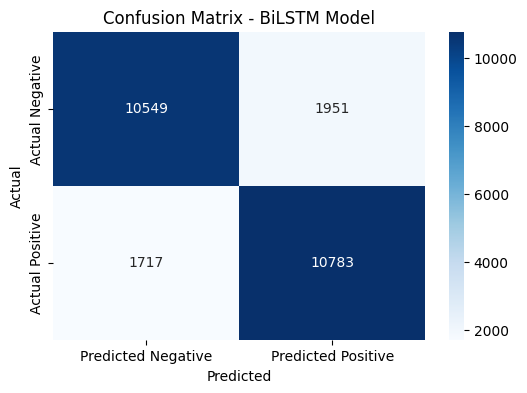

In [21]:
# Support code for Question 2.3
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Check class distribution to prove the dataset is balanced
train_pos = np.sum(y_train == 1)
train_neg = np.sum(y_train == 0)
test_pos = np.sum(y_test == 1)
test_neg = np.sum(y_test == 0)

print("--- CLASS DISTRIBUTION CHECK ---")
print(f"Train set: {train_pos} Positive | {train_neg} Negative -> Ratio: {train_pos/(train_pos+train_neg)*100:.2f}% / {train_neg/(train_pos+train_neg)*100:.2f}%")
print(f"Test set:  {test_pos} Positive | {test_neg} Negative -> Ratio: {test_pos/(test_pos+test_neg)*100:.2f}% / {test_neg/(test_pos+test_neg)*100:.2f}%\n")

# 2. Use Confusion Matrix and Classification Report for deeper evaluation
# Note: Using 'model_bilstm' as an example; you can replace it with another model (e.g., model_gru)
print("--- DEEP EVALUATION WITH ADDITIONAL METRICS (BiLSTM Model) ---")

# Predict on the test set (results are probabilities between 0 and 1)
y_pred_probs = model_bilstm.predict(X_test, verbose=0)

# Convert probabilities to labels (0 or 1) using a 0.5 threshold
y_pred_labels = (y_pred_probs > 0.5).astype(int)

# Print Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred_labels, target_names=['Negative (0)', 'Positive (1)']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix - BiLSTM Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Class Distribution: No, the IMDB dataset is perfectly balanced (exactly 50% positive and 50% negative).

Influence on Metrics: Because the classes are equal, Accuracy is a valid and reliable primary metric. If the data were imbalanced, accuracy would be misleading.

Better Evaluation Metrics: To deeply understand the model's performance, we should also use:

Confusion Matrix: To visualize exactly what type of mistakes the model makes (False Positives vs. False Negatives).

Precision, Recall, and F1-Score: To ensure the model predicts both sentiments equally well, rather than being biased toward one class.

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.4

1. Keeping Longer Sequences (Richer Context):

Pros: Preserves the complete narrative and long-range dependencies. It ensures no critical sentiment cues are lost, which is especially important for reviews that build up context and reveal their true sentiment (or a plot twist) at the very end.

Cons: Drastically increases memory (RAM/VRAM) usage and training time because RNNs process tokens sequentially step-by-step (Backpropagation Through Time). It also exacerbates the vanishing gradient problem and wastes computational resources on padding 0s if the majority of reviews are actually short.

2. Truncating Sequences (Faster Training & Lower Memory):

Pros: Significantly speeds up training and reduces memory footprint. It creates a standardized, efficient matrix size for batch processing and avoids excessive calculations on useless padding tokens.

Cons: Risks information loss. If a review is truncated, the model might drop the most important sentences at the end, leaving it with incomplete context and potentially lowering classification accuracy.

Conclusion: A balanced maximum sequence length (like MAX_SEQUENCE_LENGTH = 250 used in our preprocessing) is optimal. It covers the full length of the vast majority of reviews while capping the extreme outliers, effectively balancing context preservation with computational speed.

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.5

1. Architectural Changes:

Implement Regularization: The most urgent fix is to add Dropout and Recurrent Dropout to the LSTM/GRU layers, as well as Spatial Dropout to the Embedding layer. This will force the model to learn robust features rather than memorizing the training data, directly mitigating the overfitting issue.

Pre-trained Word Embeddings: Instead of training the Embedding layer from scratch, we can use pre-trained embeddings like GloVe or Word2Vec. These embeddings have already learned deep semantic relationships from billions of words, which would give the model a much stronger baseline understanding of sentiment-bearing words.

Adding Attention Mechanisms: Integrating an Attention layer on top of the BiLSTM/BiGRU would allow the model to focus specifically on the most critical sentiment words in a review, regardless of their position in the sequence, leading to higher accuracy and better interpretability.

2. Different Preprocessing Strategies:

Deeper Text Cleaning: The raw IMDB dataset contains HTML tags (like <br />), punctuations, and mixed cases. Applying strict cleaning (e.g., removing HTML tags, lemmatization to group words like "running" and "ran" into "run") would reduce vocabulary noise.

Subword Tokenization: Instead of word-level tokenization which converts rare words to [UNK], we could use subword algorithms like Byte-Pair Encoding (BPE) or WordPiece. This allows the model to handle unseen words by breaking them down into familiar sub-components (e.g., "unhappiness" -> "un" + "happiness").

3. Alternative Evaluation and Training Methods:

Early Stopping and Model Checkpoint: Instead of forcing the model to train for a fixed 20 epochs, we should implement the EarlyStopping callback. This will halt training automatically when the validation loss stops improving, saving time and preventing the model from over-optimizing on the training set. We can pair this with ModelCheckpoint to save the weights that achieved the best validation score.